# Plotting and reporting

A portfolio is only as useful as your ability to explain it. `PortfolioOptimisers.jl` ships a
plotting layer (loaded by bringing in `StatsPlots` and `GraphRecipes` alongside the package) that
covers the whole pipeline: the inputs, the allocation, where the risk sits, realised performance,
and the risk/return geometry — plus one-call dashboards that assemble several views at once. This
page is a guided tour of the reporting toolkit on a single worked portfolio.

> **When to reach for this**
>
> Reach for these at the end of every analysis — to sanity-check inputs before optimising, to
> communicate an allocation, and to compare candidate strategies on the same axes. The
> individual plots are building blocks; the dashboards (`plot_portfolio_dashboard`,
> `plot_performance_summary`) are the fastest way to a complete picture.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, Clarabel, StatsPlots, GraphRecipes

## 1. A worked portfolio

We build an empirical prior, a minimum-risk and a maximum-ratio book to compare, and an efficient
frontier for the geometry plots.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

res_min = optimise(MeanRisk(; obj = MinimumRisk(),
                            opt = JuMPOptimiser(; pe = pr, slv = slv)))
res_ratio = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                              opt = JuMPOptimiser(; pe = pr, slv = slv)))
frontier = optimise(MeanRisk(; obj = MinimumRisk(),
                             opt = JuMPOptimiser(; pe = pr, slv = slv,
                                                 ret = ArithmeticReturn(;
                                                                        lb = Frontier(;
                                                                                      N = 15)))))

MeanRiskResult
  jr ┼ JuMPOptimisationResult
     │        oe ┼ DataType: DataType
     │        pa ┼ ProcessedJuMPOptimiserAttributes
     │           │        pr ┼ LowOrderPrior
     │           │           │         X ┼ 252×20 Matrix{Float64}
     │           │           │        mu ┼ 20-element Vector{Float64}
     │           │           │     sigma ┼ 20×20 Matrix{Float64}
     │           │           │      chol ┼ nothing
     │           │           │         w ┼ nothing
     │           │           │       ens ┼ nothing
     │           │           │       kld ┼ nothing
     │           │           │        ow ┼ nothing
     │           │           │        rr ┼ nothing
     │           │           │      f_mu ┼ nothing
     │           │           │   f_sigma ┼ nothing
     │           │           │       f_w ┴ nothing
     │           │        wb ┼ WeightBounds
     │           │           │   lb ┼ 20-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePreci

## 2. Inspecting the inputs

Before trusting an optimisation, look at what fed it. `plot_prior` summarises the prior in
one figure; `plot_correlation` and `plot_mu` zoom in on the covariance structure
and the expected returns.

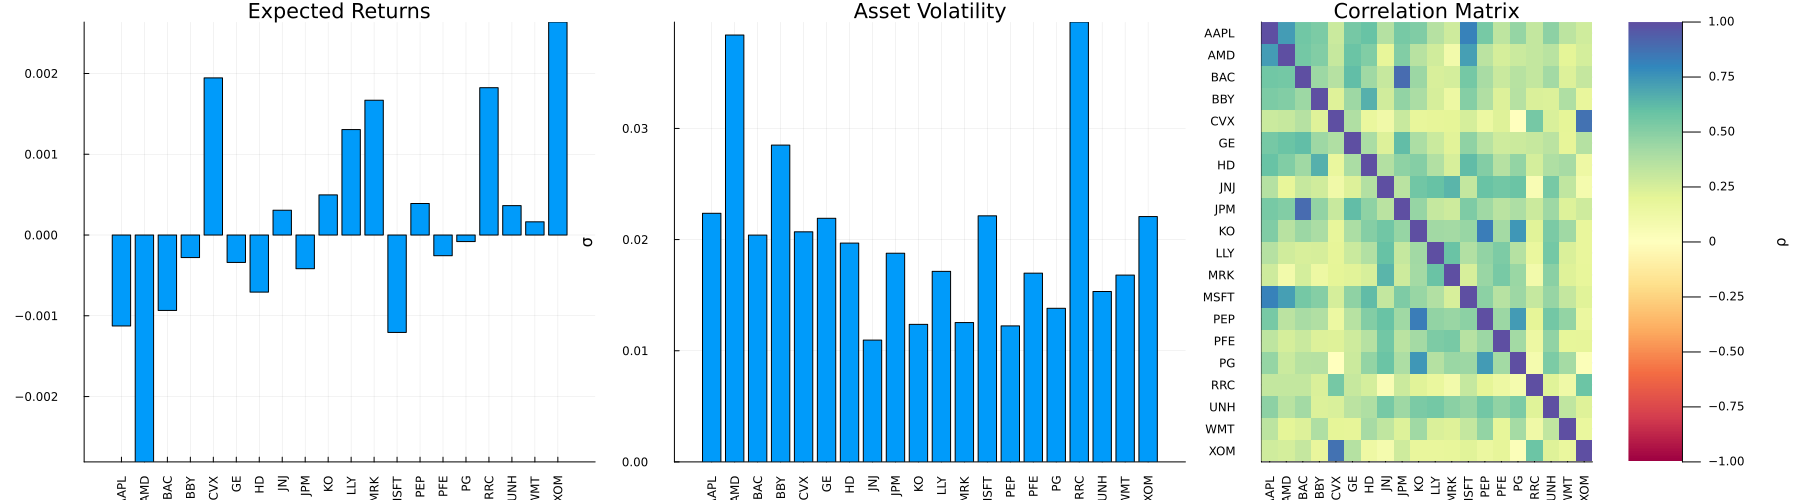

In [3]:
plot_prior(pr, rd)

The correlation matrix on its own.

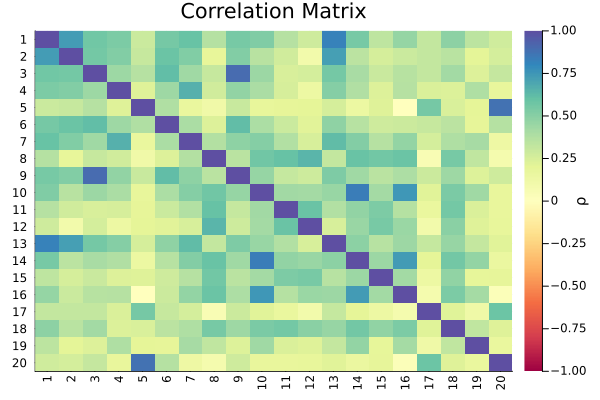

In [4]:
plot_correlation(pr)

## 3. The allocation

`plot_stacked_bar_composition` puts candidate books side by side — here minimum-risk
versus maximum-ratio — making the difference in concentration immediate.

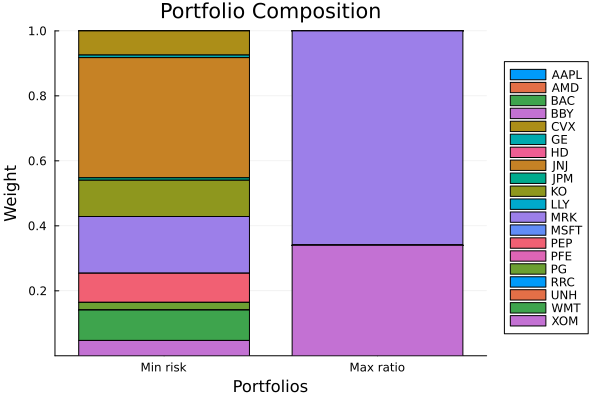

In [5]:
plot_stacked_bar_composition([res_min, res_ratio], rd;
                             xticks = (1:2, ["Min risk", "Max ratio"]))

## 4. Where the risk sits

A book can look diversified by weight but be concentrated in *risk*.
`plot_risk_contribution` decomposes the portfolio risk by asset. The risk measure comes
first, and it must be **configured for the data**: pass `factory(Variance(), pr)` rather than a
bare `Variance()` (a bare quadratic risk measure has no covariance attached yet — see the findings
note). Return-based measures like `ConditionalValueatRisk` need no factory.

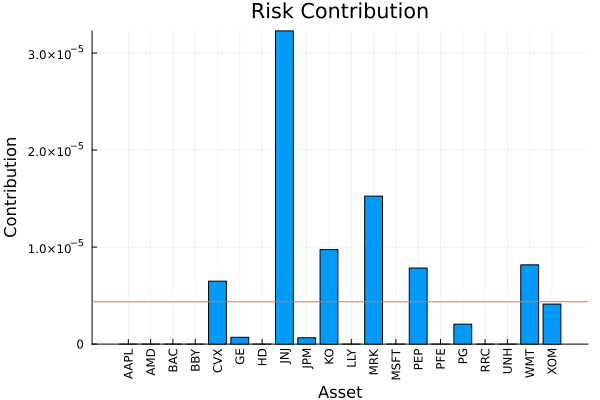

In [6]:
plot_risk_contribution(factory(Variance(), pr), res_min, rd)

## 5. Realised performance

`plot_ptf_cumulative_returns` and `plot_drawdowns` show how the book would have
behaved over the sample, and `plot_performance_summary` collects the headline performance
views into one figure.

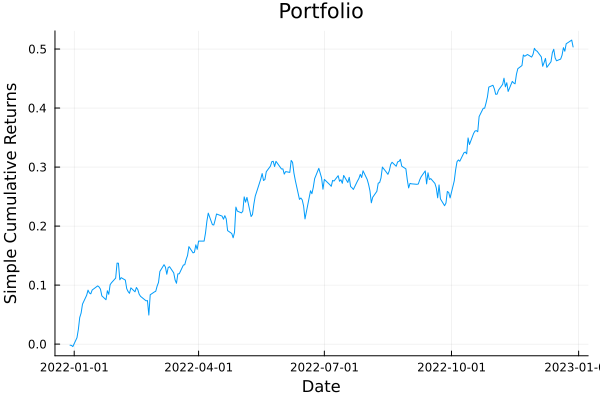

In [7]:
plot_ptf_cumulative_returns(res_ratio.w, rd)

The drawdown profile.

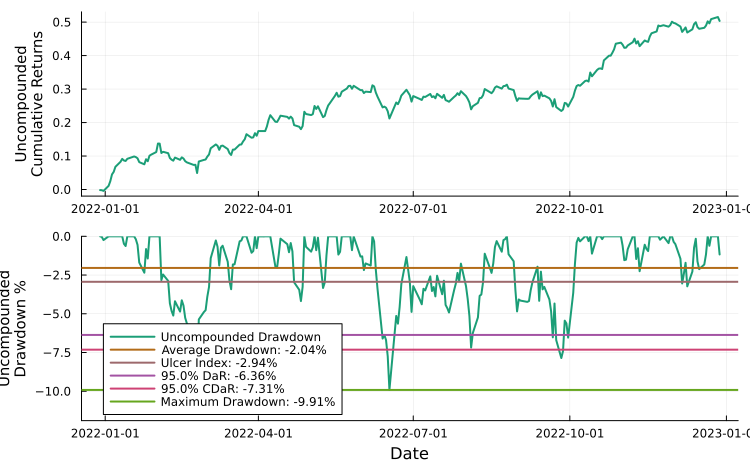

In [8]:
plot_drawdowns(res_ratio.w, rd)

## 6. Risk/return geometry

`plot_measures` scatters portfolios on any pair of risk/return axes, and
`plot_efficient_frontier` draws the frontier itself — the trade-off surface the optimiser
traced out.

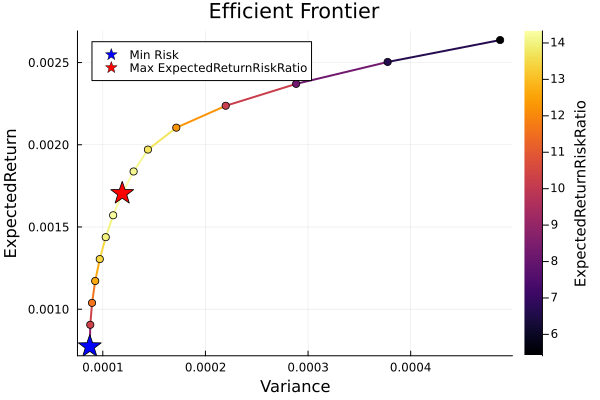

In [9]:
plot_efficient_frontier(frontier.w, pr; rt = frontier.ret)

## 7. The dashboard

`plot_portfolio_dashboard` assembles composition, risk, and performance into a single
report — the fastest way to a complete picture of one book.

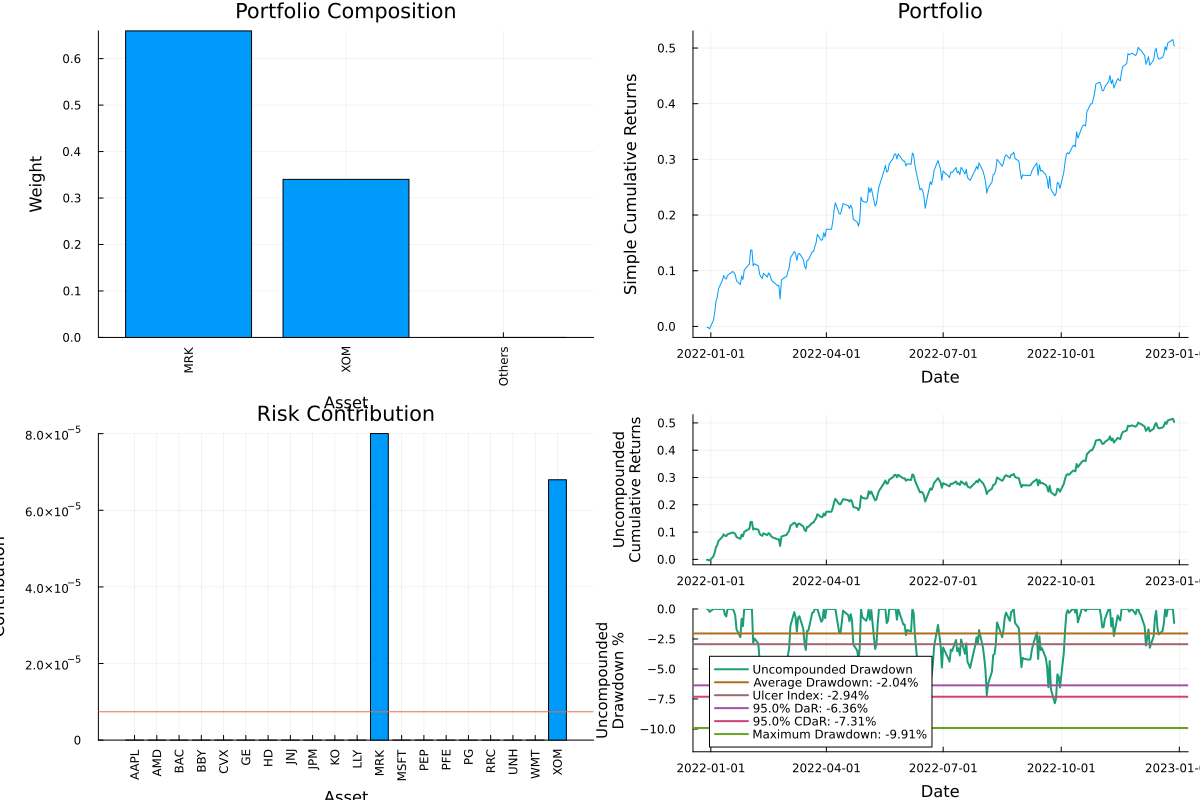

In [10]:
plot_portfolio_dashboard(res_ratio, rd; r = factory(Variance(), pr))

This is a selection, not the whole catalogue. The same layer also offers network and clustering
views (`plot_network`, `plot_dendrogram`, `plot_clusters`,
`plot_centrality`), validation plots (`plot_cv_scores`,
`plot_cv_dashboard`), cost/turnover plots (`plot_turnover`), and higher-moment
views (`plot_coskewness`, `plot_cokurtosis`) — each following the same
`plot_*(subject, …)` convention.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*